In [3]:
import os, re, random, math
from pathlib import Path

import numpy as np
import pandas as pd

from PIL import Image
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, confusion_matrix, accuracy_score

## 1) Data loading

In [5]:
CANDIDATES = [
    "/kaggle/input/utkface-new/crop_part1",
    "/kaggle/input/utkface-new/UTKFace",
    "/kaggle/input/utk-face-cropped/UTKFace",
    "/content/UTKFace",
    "/content/crop_part1",
]

DATA_DIR = None
for p in CANDIDATES:
    if os.path.isdir(p):
        DATA_DIR = p
        break

DATA_DIR

'/kaggle/input/utkface-new/crop_part1'

In [6]:
if DATA_DIR is None:
    raise FileNotFoundError(
        "Не нашёл UTKFace автоматически. Укажи путь к папке с jpg в переменной DATA_DIR."
    )

DATA_DIR = Path(DATA_DIR)
files = sorted([p for p in DATA_DIR.glob("*.jpg")])
len(files), files[0].name if files else None

(9780, '100_1_0_20170110183726390.jpg.chip.jpg')

## 2) Парсинг лейблов из имени файла

Ожидаемый формат: `age_gender_race_date.jpg`  
- `age` — целое число (0..116)  
- `gender` — 0/1 (обычно 0=male, 1=female, но в разных версиях датасета встречаются вариации)  
- `race` — 0..4 (кодировка из UTKFace)


In [7]:
pat=re.compile(r"^(\d+)_(\d+)_(\d+)_([0-9]+)\.jpg(?:\.chip)?\.jpg$")

rows=[]
bad=0
for fp in files:
    m = pat.match(fp.name)
    if not m:
        bad += 1
        continue
    age = int(m.group(1))
    gender = int(m.group(2))
    race = int(m.group(3))
    date = m.group(4)
    rows.append((str(fp), age, gender, race, date))

df = pd.DataFrame(rows, columns=["path","age","gender","race","date"])
bad, df.shape

(2, (9778, 5))

In [8]:
df

,path,age,gender,race,date
0,/kaggle/input/utkface-new/crop_part1/100_1_0_2...,100,1,0,20170110183726390
1,/kaggle/input/utkface-new/crop_part1/100_1_2_2...,100,1,2,20170105174847679
2,/kaggle/input/utkface-new/crop_part1/101_1_2_2...,101,1,2,20170105174739309
3,/kaggle/input/utkface-new/crop_part1/10_0_0_20...,10,0,0,20161220222308131
4,/kaggle/input/utkface-new/crop_part1/10_0_0_20...,10,0,0,20170103200329407
...,...,...,...,...,...
9773,/kaggle/input/utkface-new/crop_part1/9_1_3_201...,9,1,3,20161220222856346
9774,/kaggle/input/utkface-new/crop_part1/9_1_3_201...,9,1,3,20170104222949455
9775,/kaggle/input/utkface-new/crop_part1/9_1_4_201...,9,1,4,20170103200637399
9776,/kaggle/input/utkface-new/crop_part1/9_1_4_201...,9,1,4,20170103200814791


### Быстрая чистка / sanity-check

- фильтруем невалидный возраст (на практике иногда бывают странные файлы)
- gender/race оставим как есть, но отдельно посмотрим на значения


In [9]:
df = df[(df["age"]>=0) & (df["age"]<=116)].copy()
df["gender"].value_counts(), df["race"].value_counts(), df.shape

(gender
 1    5406
 0    4372
 Name: count, dtype: int64,
 race
 0    5265
 2    1553
 3    1452
 4    1103
 1     405
 Name: count, dtype: int64,
 (9778, 5))

## 3) EDA: распределение возраста

Ключевое, что почти всегда видно на UTKFace:
- **дисбаланс по возрасту** (много 20–40, меньше детей и пожилых);
- хвосты (80+), редкие возраста → модели сложно учить стабильные паттерны;
- лейбл “возраст” шумный, т.к. это не паспортные данные, и часто возраст визуально неоднозначен.


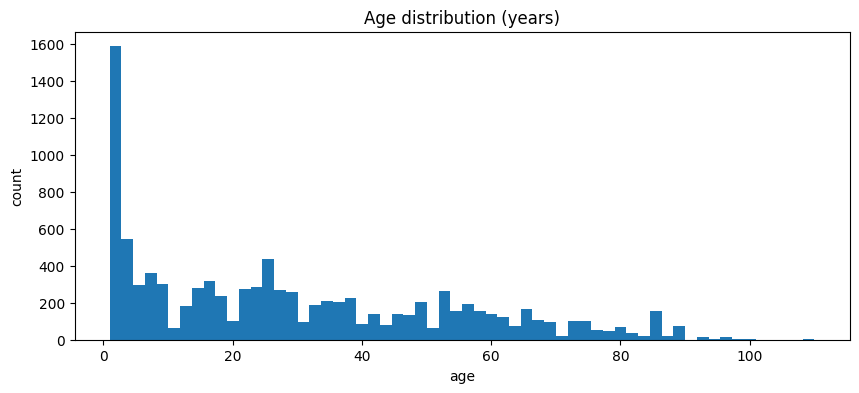

count    9778.000000
mean       29.415116
std        24.775750
min         1.000000
25%         7.000000
50%        25.000000
75%        49.000000
max       110.000000
Name: age, dtype: float64

In [13]:
plt.figure(figsize=(10,4))
plt.hist(df["age"], bins=60)
plt.title("Age distribution (years)")
plt.xlabel("age"); plt.ylabel("count")
plt.show()

df["age"].describe()

### Возрастные группы (age bins)

Для “интерпретируемых” метрик (accuracy по группам, confusion matrix) заведём корзины.
Корзины можно поменять под ваш проект, но эти чаще всего удобны:
- 0–2 (infants)
- 3–12 (kids)
- 13–19 (teens)
- 20–29, 30–39, 40–49, 50–59, 60–69, 70–79
- 80+ (very old)

Почему так: детям (и подросткам) обычно сложнее, т.к. лицо быстро меняется по годам, и классы “ближе” друг к другу.


In [14]:
bins = [0,3,13,20,30,40,50,60,70,80,117]
labels = ["0-2","3-12","13-19","20-29","30-39","40-49","50-59","60-69","70-79","80+"]

df["age_bin"] = pd.cut(df["age"], bins=bins, right=False, labels=labels)
df["age_bin"].value_counts().reindex(labels)

age_bin
0-2      1587
3-12     1668
13-19     909
20-29    1517
30-39    1034
40-49     675
50-59     938
60-69     654
70-79     379
80+       417
Name: count, dtype: int64

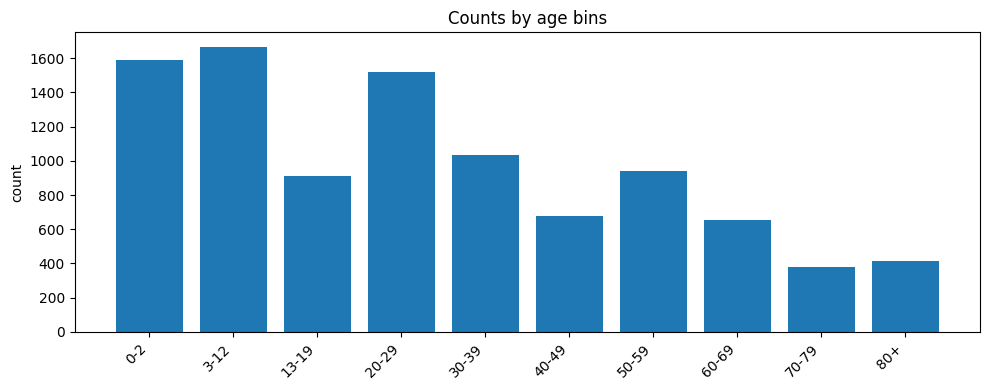

In [15]:
plt.figure(figsize=(10,4))
counts = df["age_bin"].value_counts().reindex(labels).fillna(0)
plt.bar(range(len(labels)), counts.values)
plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
plt.title("Counts by age bins")
plt.ylabel("count")
plt.tight_layout()
plt.show()

## 4) EDA: gender / race и их связь с возрастом

Это нужно по двум причинам:
1) понять **смещение/дисбаланс** в данных (и потенциальный bias модели);
2) заранее придумать **стратификацию** при train/val split и мониторинг метрик по подгруппам.


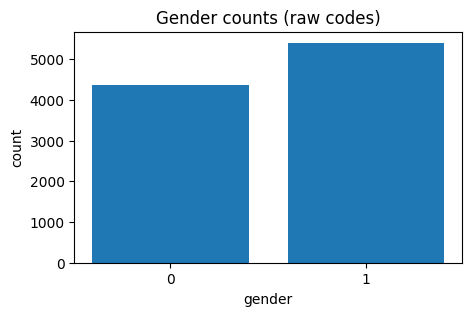

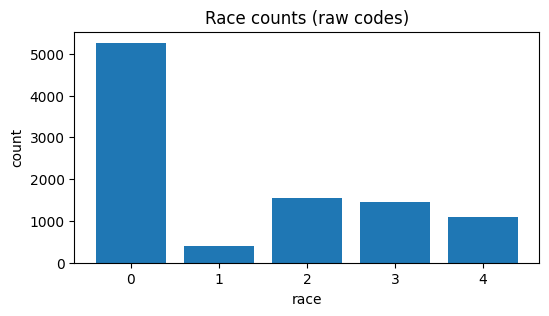

In [16]:
plt.figure(figsize=(5,3))
gvc = df["gender"].value_counts().sort_index()
plt.bar(gvc.index.astype(str), gvc.values)
plt.title("Gender counts (raw codes)")
plt.xlabel("gender"); plt.ylabel("count")
plt.show()

plt.figure(figsize=(6,3))
rvc = df["race"].value_counts().sort_index()
plt.bar(rvc.index.astype(str), rvc.values)
plt.title("Race counts (raw codes)")
plt.xlabel("race"); plt.ylabel("count")
plt.show()

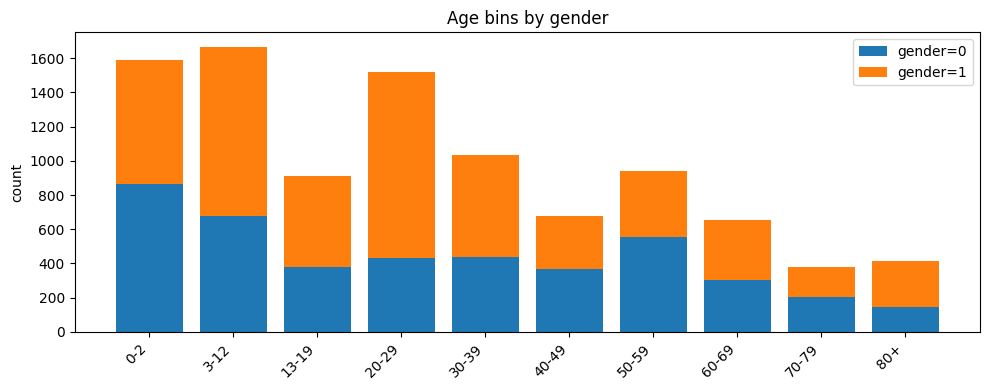

In [17]:
# age-bin vs gender (stacked)
ct = pd.crosstab(df["age_bin"], df["gender"]).reindex(labels).fillna(0)

plt.figure(figsize=(10,4))
bottom = np.zeros(len(ct))
for col in ct.columns:
    vals = ct[col].values
    plt.bar(range(len(ct)), vals, bottom=bottom, label=f"gender={col}")
    bottom += vals

plt.xticks(range(len(ct)), labels, rotation=45, ha="right")
plt.title("Age bins by gender")
plt.ylabel("count")
plt.legend()
plt.tight_layout()
plt.show()

## 5) Визуальная проверка: примеры по возрастным группам

Это быстрый способ поймать:
- кривые обрезки, окклюзии, низкое качество;
- “невероятные” возраста (лейбл шумный);
- возможные дубликаты/серии.


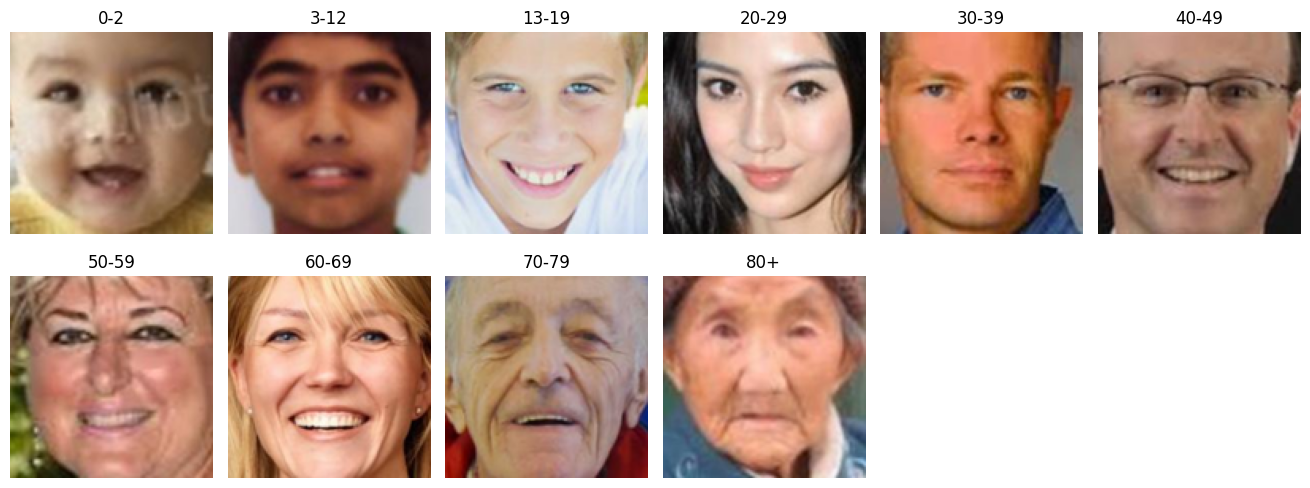

In [18]:
def show_examples(df, by="age_bin", n=12, seed=42, img_size=128):
    rnd = random.Random(seed)
    groups = df.groupby(by, observed=True)
    keys = [k for k,_ in groups]
    keys = [k for k in keys if pd.notna(k)]
    keys = sorted(keys, key=lambda x: labels.index(str(x)) if str(x) in labels else 999)

    picked=[]
    for k in keys:
        g = groups.get_group(k)
        fp = rnd.choice(g["path"].tolist())
        picked.append((k, fp))

    if not picked:
        print("Нет данных для отображения")
        return

    cols = min(6, len(picked))
    rows = math.ceil(len(picked)/cols)
    plt.figure(figsize=(cols*2.2, rows*2.6))
    for i,(k,fp) in enumerate(picked):
        ax = plt.subplot(rows, cols, i+1)
        try:
            img = Image.open(fp).convert("RGB").resize((img_size,img_size))
            ax.imshow(img)
        except Exception as e:
            ax.text(0.5,0.5,str(e),ha="center",va="center")
        ax.set_title(str(k))
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_examples(df, by="age_bin")

## 6) Train/Val split: что важно

Обычно для UTKFace достаточно:
- random split, но **стратифицировать по age_bin**, чтобы в val не исчезли редкие возраста;
- зафиксировать seed;
- отдельно следить за метриками по bin (и по gender/race, если это критично).

**Важно:** возможны почти-dup / серии с одной персоной. Идеально — split по identity, но в UTKFace identity нет, поэтому хотя бы проверяем near-duplicates (опционально).


In [19]:
train_df, val_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df["age_bin"]
)
train_df.shape, val_df.shape, train_df["age_bin"].value_counts().min(), val_df["age_bin"].value_counts().min()

((7822, 6), (1956, 6), 303, 76)

## 7) Метрики

### Основная: RMSE (Root Mean Squared Error)

Почему “RMSE forever”:
- возраст — **непрерывная** величина → это регрессия;
- RMSE сильнее штрафует большие ошибки (например, *ребёнка* предсказать как 30 — это очень плохо).

\[
\mathrm{RMSE}=\sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat y_i)^2}
\]

### Дополнительные (для отчёта и дебага)
- **MAE**: \(\frac{1}{n}\sum |y-\hat y|\) — легче интерпретировать (в “годах”).
- **Accuracy@k**: доля примеров, где \(|y-\hat y|\le k\) (обычно k=5 или 10).
- **Age-bin accuracy + Confusion Matrix**: переводим возраст в группы и смотрим, где именно модель путается (kids vs teens и т.п.).


In [20]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mae(y_true, y_pred):
    return float(mean_absolute_error(y_true, y_pred))

def acc_at_k(y_true, y_pred, k=5):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.mean(np.abs(y_true - y_pred) <= k))

def to_bin(a):
    # a can be scalar or array
    return pd.cut(pd.Series(a), bins=bins, right=False, labels=labels).astype(str).values

def plot_confmat(y_true_bin, y_pred_bin, title="Confusion matrix"):
    cm = confusion_matrix(y_true_bin, y_pred_bin, labels=labels)
    plt.figure(figsize=(8,6))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("pred"); plt.ylabel("true")
    plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
    plt.yticks(range(len(labels)), labels)
    plt.colorbar()
    plt.tight_layout()
    plt.show()
    return cm

### Бейзлайн 0: “предсказываем средний возраст”

Это не про качество, а про **минимальную точку отсчёта**: насколько вообще сложна задача по сравнению с тривиальным предиктором.


In [21]:
y_tr = train_df["age"].values
y_va = val_df["age"].values

pred_mean = np.full_like(y_va, fill_value=y_tr.mean(), dtype=float)

metrics = {
    "RMSE": rmse(y_va, pred_mean),
    "MAE": mae(y_va, pred_mean),
    "Acc@5": acc_at_k(y_va, pred_mean, k=5),
    "Acc@10": acc_at_k(y_va, pred_mean, k=10),
}
metrics

{'RMSE': 24.708678348095418,
 'MAE': 20.775275048771775,
 'Acc@5': 0.13394683026584867,
 'Acc@10': 0.2607361963190184}

## 8) Какие возрастные группы “похожи” и будут путаться?

На этой стадии можно сделать честную, но простую вещь:
- взять **типичный уровень ошибки** (например, RMSE ~ 7 лет — часто встречается в базовых Kaggle-решениях на UTKFace),
- смоделировать предсказание как `y_pred = y_true + N(0, σ^2)` и посмотреть confusion matrix по age-bins.

Это не заменяет реальную модель, но даёт быстрый ответ:
- **где границы групп самые проблемные**,
- какие bins будут чаще переходить друг в друга при разумном уровне ошибки.


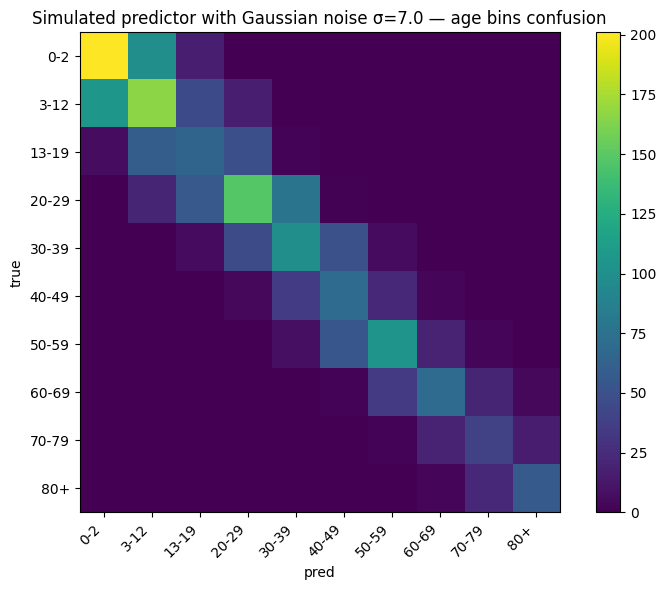

In [23]:
sigma = 7.0  # можно менять (идея: соответствует "типичному" RMSE)
rng = np.random.default_rng(42)

sim_pred = y_va + rng.normal(0, sigma, size=len(y_va))
sim_pred = np.clip(sim_pred, 0, 116)

sim_bin = to_bin(sim_pred)

_ = plot_confmat(true_bin, sim_bin, title=f"Simulated predictor with Gaussian noise σ={sigma} — age bins confusion")

### Ошибка по возрастным группам (ожидаемая)

Для моделей на UTKFace часто наблюдается:
- лучше на “массовых” возрастах (20–50),
- хуже на редких и быстро меняющихся (дети/подростки) и на хвостах (80+).

Сейчас посчитаем на симуляции, чтобы увидеть “форму” проблемы.


In [24]:
tmp = val_df.copy()
tmp["pred_sim"] = sim_pred
tmp["abs_err"] = np.abs(tmp["age"] - tmp["pred_sim"])
tmp["sq_err"] = (tmp["age"] - tmp["pred_sim"])**2

by = tmp.groupby("age_bin", observed=True).agg(
    n=("age","size"),
    mae=("abs_err","mean"),
    rmse=("sq_err", lambda x: float(np.sqrt(np.mean(x)))),
).reindex(labels)

by

,n,mae,rmse
age_bin,,,
0-2,317,3.234215,4.865489
3-12,334,4.628659,5.913071
13-19,182,5.416761,6.567440
20-29,303,5.565088,6.924263
30-39,207,5.812576,7.236400
40-49,135,5.421156,6.963956
50-59,188,5.316458,6.843608
60-69,131,5.632101,7.030830
70-79,76,5.266077,6.454805


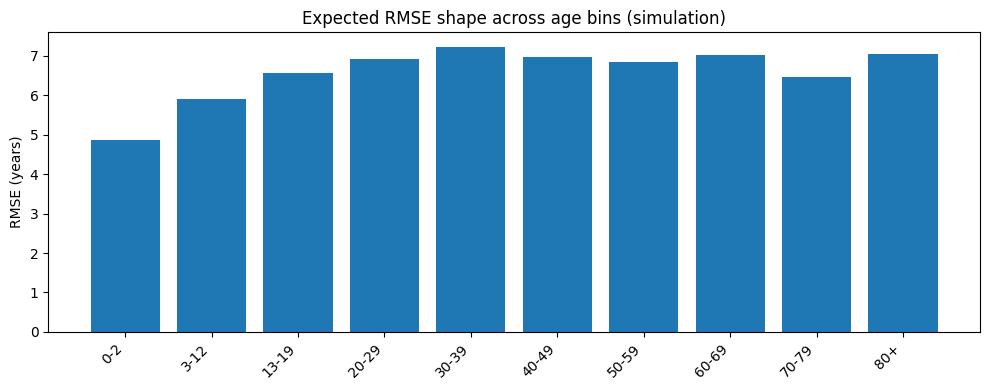

In [26]:
plt.figure(figsize=(10,4))
plt.bar(range(len(labels)), by["rmse"].values)
plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
plt.title("Expected RMSE shape across age bins (simulation)")
plt.ylabel("RMSE (years)")
plt.tight_layout()
plt.show()

## 9) Предварительные выводы 

### 1) Дисбаланс по возрасту
**Проблема:** модель “тянет” прогноз к 20–40 (где много данных), редкие возраста учатся плохо.  
**Лечение:**
- стратифицированный split по age_bin;
- **re-weighting**: веса в loss по обратной частоте age_bin;
- **oversampling** редких bin / balanced batch sampler;
- мониторинг метрик **по bin**, а не только общая RMSE.

### 2) Шум в лейбле возраста
**Проблема:** возраст по фото субъективен, “похожие” лица могут отличаться на 5–10 лет.  
**Лечение:**
- более робастный loss: **Huber / SmoothL1** вместо чистого MSE;
- предсказывать **ожидаемое значение + дисперсию** (uncertainty), если хочется глубже;
- как альтернатива: **ordinal regression / age-bins classification** (и потом переводить в годы).

### 3) Границы групп (kids/teens) и хвосты (80+)
**Проблема:** именно там чаще всего будут большие ошибки и путаница.  
**Лечение:**
- аугментации + больше данных (если можно);
- отдельный мониторинг: RMSE/MAE по bins, confusion matrix;
- возможно, сделать “двухуровневую” постановку: сначала bin, потом регрессия внутри.

### 4) Bias / fairness (gender/race)
**Проблема:** распределения могут быть перекошены, и качество по подгруппам будет разным.  
**Лечение:**
- мониторинг метрик по подгруппам;
- если задача “продуктовая” — определить, что допустимо использовать и что нет.

### 5) Проблемы данных: качество, окклюзии, разные условия съёмки
**Лечение:**
- сильные аугментации (blur, JPEG, lighting, crop/resize);
- использование предобученных backbone (ResNet/EfficientNet/MobileNet) и fine-tune.

